<a href="https://colab.research.google.com/github/ONESFA/PINNs-and-FDM-FEM/blob/main/PINNS_%EA%B5%AC%ED%98%84_%EC%99%84.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

필요한 모듈 설치


In [46]:
import torch
import torch.nn as nn

# 1번: 데이터 포인트 입력(Collcation Points)


In [47]:
# ============================================
# 1. Collocation Point 개수 설정
# ============================================

N_f = 100    # PDE를 검사할 내부 점 개수
N_bc = 100   # 경 조건을 검사할 전체 점 개수
N_ic = 100   # 초기 조건을 검사할 전체 점 개수

In [48]:
# ============================================
# 2. PDE 내부 영역의 Collocation Points
# ============================================

x_f = torch.rand(N_f, 1)  #3개다 0 부터 1 사이의 범위에서 랜덤한 점 생성
y_f = torch.rand(N_f, 1)
t_f = torch.rand(N_f, 1)

In [49]:
# ============================================
# 3. Boundary Condition Points
# ============================================

N_each = N_bc // 4  # 전체 경계점이 100개니까 25개씩 배분하자

# -------------------------
# 경계 1 : x = 0
# -------------------------
x_bc_1 = torch.zeros(N_each, 1)
y_bc_1 = torch.rand(N_each, 1)
t_bc_1 = torch.rand(N_each, 1)


# -------------------------
# 경계 2 : x = 1
# -------------------------
x_bc_2 = torch.ones(N_each, 1)
y_bc_2 = torch.rand(N_each, 1)
t_bc_2 = torch.rand(N_each, 1)


# -------------------------
# 경계 3 : y = 0
# -------------------------
x_bc_3 = torch.rand(N_each, 1)
y_bc_3 = torch.zeros(N_each, 1)
t_bc_3 = torch.rand(N_each, 1)


# -------------------------
# 경계 4 : y = 1
# -------------------------
x_bc_4 = torch.rand(N_each, 1)
y_bc_4 = torch.ones(N_each, 1)
t_bc_4 = torch.rand(N_each, 1)

In [50]:
# ============================================
# 4. Boundary Points 합치
# ============================================

x_bc = torch.cat([
    x_bc_1,
    x_bc_2,
    x_bc_3,
    x_bc_4
], dim=0)

y_bc = torch.cat([
    y_bc_1,
    y_bc_2,
    y_bc_3,
    y_bc_4
], dim=0)

t_bc = torch.cat([
    t_bc_1,
    t_bc_2,
    t_bc_3,
    t_bc_4
], dim=0)

In [51]:
# ============================================
# 5. Initial Condition Points
# ============================================

x_ic = torch.rand(N_ic, 1)
y_ic = torch.rand(N_ic, 1)

t_ic = torch.zeros(N_ic, 1)

In [52]:
# ============================================
# 6. Initial Condition Values
# ============================================

# 초기 변위
u_ic = (
    torch.sin(torch.pi * x_ic)
    * torch.sin(torch.pi * y_ic)
)

# 초기 속도
v_ic = torch.zeros_like(u_ic)

# **2번 심층 신경망 근사**

PINN 신경망 정의

In [53]:
class PINN(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(3, 50),   #선형변환 + 가중치, (x,y,t)의 입력값이니 3
            nn.Tanh(),          #활성화 함수는 Tanh로 하자

            nn.Linear(50, 50),
            nn.Tanh(),

            nn.Linear(50, 50),
            nn.Tanh(),

            nn.Linear(50, 50),
            nn.Tanh(),

            nn.Linear(50, 1)    #출력층
        )

    def forward(self, x, y, t):   #순방향 형태

        inputs = torch.cat([x, y, t], dim=1)

        return self.net(inputs)

PINNS 모델 생성 및 출력 확인

In [54]:
model = PINN()

In [55]:
u_pred = model(
    x_f,
    y_f,
    t_f
)

print(u_pred.shape)

torch.Size([100, 1])


# **3번 미분 연산 및 손실(Loss) 계산 모듈**

In [56]:
# ============================================
# PDE Residual
# ============================================

def pde_residual(model, x, y, t, c=1.0):

    # 자동미분을 위해 입력값에 gradient 추적 설정
    x = x.clone().detach().requires_grad_(True)
    y = y.clone().detach().requires_grad_(True)
    t = t.clone().detach().requires_grad_(True)

    # 신경망 출력
    u = model(x, y, t)

    # --------------------------------
    # 1차 미분
    # --------------------------------

    u_x = torch.autograd.grad(
        u,
        x,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    u_y = torch.autograd.grad(
        u,
        y,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    u_t = torch.autograd.grad(
        u,
        t,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    # --------------------------------
    # 2차 미분
    # --------------------------------

    u_xx = torch.autograd.grad(
        u_x,
        x,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True
    )[0]

    u_yy = torch.autograd.grad(
        u_y,
        y,
        grad_outputs=torch.ones_like(u_y),
        create_graph=True
    )[0]

    u_tt = torch.autograd.grad(
        u_t,
        t,
        grad_outputs=torch.ones_like(u_t),
        create_graph=True
    )[0]

    # --------------------------------
    # 2차원 파동방정식
    # u_tt - c^2(u_xx + u_yy) = 0
    # --------------------------------

    residual = (
        u_tt
        - c**2 * (u_xx + u_yy)
    )

    return residual


Loss 다 합친거 함수


In [57]:
def loss_pde(model, x_f, y_f, t_f, c=1.0): #c는 상수이므로 1로 가정

    residual = pde_residual(
        model,
        x_f,
        y_f,
        t_f,
        c
    )

    L_pde = torch.mean(residual ** 2)

    return L_pde

Initial Displacement Loss

In [58]:
def loss_ic(model, x_ic, y_ic, u_ic):

    t_ic = torch.zeros_like(x_ic)

    u_pred = model(
        x_ic,
        y_ic,
        t_ic
    )

    L_ic = torch.mean(
        (u_pred - u_ic) ** 2
    )

    return L_ic

Initial Velocity Loss

In [59]:
def loss_ic_velocity(model, x_ic, y_ic, v_ic):

    t_ic = torch.zeros_like(x_ic)
    t_ic.requires_grad_(True)

    u_pred = model(
        x_ic,
        y_ic,
        t_ic
    )

    u_t = torch.autograd.grad(
        u_pred,
        t_ic,
        grad_outputs=torch.ones_like(u_pred),
        create_graph=True
    )[0]

    L_ic_velocity = torch.mean(
        (u_t - v_ic) ** 2
    )

    return L_ic_velocity

Boundary Condition Loss

In [60]:
def loss_bc(model, x_bc, y_bc, t_bc):

    u_pred = model(
        x_bc,
        y_bc,
        t_bc
    )

    L_bc = torch.mean(
        u_pred ** 2
    )

    return L_bc

Total

In [61]:
def total_loss(
    model,
    x_f, y_f, t_f,
    x_bc, y_bc, t_bc,
    x_ic, y_ic,
    u_ic,
    v_ic,
    c=1.0,
    w_pde=1.0,
    w_bc=1.0,
    w_ic=1.0,
    w_ic_velocity=1.0 #처음 가중치는 일단 1씩
):

    L_pde = loss_pde(
        model,
        x_f, y_f, t_f,
        c
    )

    L_bc = loss_bc(
        model,
        x_bc, y_bc, t_bc
    )

    L_ic = loss_ic(
        model,
        x_ic, y_ic,
        u_ic
    )

    L_ic_velocity = loss_ic_velocity(  #2차의 파동함수 이므로 초기변위(초기속도)를 맞춰야 한다
        model,
        x_ic, y_ic,
        v_ic
    )

    L_loss = (
        w_pde * L_pde
        + w_bc * L_bc
        + w_ic * L_ic
        + w_ic_velocity * L_ic_velocity
    ) #가중치 들어감

    return (
        L_loss,
        L_pde,
        L_bc,
        L_ic,
        L_ic_velocity
    )

손실 함수들의 실행 코드


In [62]:
L_loss, L_pde, L_bc, L_ic, L_ic_velocity = total_loss(
    model,
    x_f, y_f, t_f,
    x_bc, y_bc, t_bc,
    x_ic, y_ic,
    u_ic,
    v_ic,
    w_pde=1.0,  # 가중치 변경 원할 시 이곳 3가지 변경
    w_bc=1.0,
    w_ic=1.0,
    w_ic_velocity=1.0
)

각각 함수들의 출력값 확인 (가중치 적용 X)

In [63]:
print("Total Loss     =", L_loss.item())
print("PDE Loss       =", L_pde.item())
print("BC Loss        =", L_bc.item())
print("IC Loss        =", L_ic.item())
print("IC Velocity    =", L_ic_velocity.item())

Total Loss     = 0.19405879080295563
PDE Loss       = 0.0005288547254167497
BC Loss        = 0.014336992055177689
IC Loss        = 0.1751982867717743
IC Velocity    = 0.0039946516044437885


# **4번 최종 손실 합산 및 최적화**

In [64]:
# ============================================
# 4. Optimization 옵티마이저 설
# ============================================

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [65]:
#모든 Loss의 가중치를 1로 설정

w_pde = 1.0
w_bc = 1.0
w_ic = 1.0
w_ic_velocity = 1.0

실제 학습 반복

In [66]:
epochs = 5000

for epoch in range(epochs):

    optimizer.zero_grad()

    L_loss, L_pde, L_bc, L_ic, L_ic_velocity = total_loss(
        model,
        x_f, y_f, t_f,
        x_bc, y_bc, t_bc,
        x_ic, y_ic,
        u_ic,
        v_ic,
        w_pde=w_pde,
        w_bc=w_bc,
        w_ic=w_ic,
        w_ic_velocity=w_ic_velocity
    )

    L_loss.backward()

    optimizer.step()

    if epoch % 500 == 0:
        print(
            f"Epoch {epoch:5d} | "
            f"Total Loss: {L_loss.item():.6e} | "
            f"PDE: {L_pde.item():.6e} | "
            f"BC: {L_bc.item():.6e} | "
            f"IC: {L_ic.item():.6e} | "
            f"IC_v: {L_ic_velocity.item():.6e}"
        )

Epoch     0 | Total Loss: 1.940588e-01 | PDE: 5.288547e-04 | BC: 1.433699e-02 | IC: 1.751983e-01 | IC_v: 3.994652e-03
Epoch   500 | Total Loss: 3.539523e-02 | PDE: 2.994915e-03 | BC: 1.458166e-02 | IC: 1.433282e-02 | IC_v: 3.485833e-03
Epoch  1000 | Total Loss: 1.664005e-02 | PDE: 1.139478e-03 | BC: 6.713173e-03 | IC: 5.184052e-03 | IC_v: 3.603347e-03
Epoch  1500 | Total Loss: 1.251617e-02 | PDE: 9.337095e-04 | BC: 5.780307e-03 | IC: 2.614117e-03 | IC_v: 3.188035e-03
Epoch  2000 | Total Loss: 1.063254e-02 | PDE: 8.282975e-04 | BC: 4.908455e-03 | IC: 2.017909e-03 | IC_v: 2.877879e-03
Epoch  2500 | Total Loss: 8.408903e-03 | PDE: 7.979012e-04 | BC: 4.150028e-03 | IC: 1.270561e-03 | IC_v: 2.190412e-03
Epoch  3000 | Total Loss: 6.154200e-03 | PDE: 7.785578e-04 | BC: 3.318527e-03 | IC: 7.706337e-04 | IC_v: 1.286482e-03
Epoch  3500 | Total Loss: 4.292950e-03 | PDE: 6.283665e-04 | BC: 2.617512e-03 | IC: 4.152156e-04 | IC_v: 6.318565e-04
Epoch  4000 | Total Loss: 3.247749e-03 | PDE: 4.155758e-

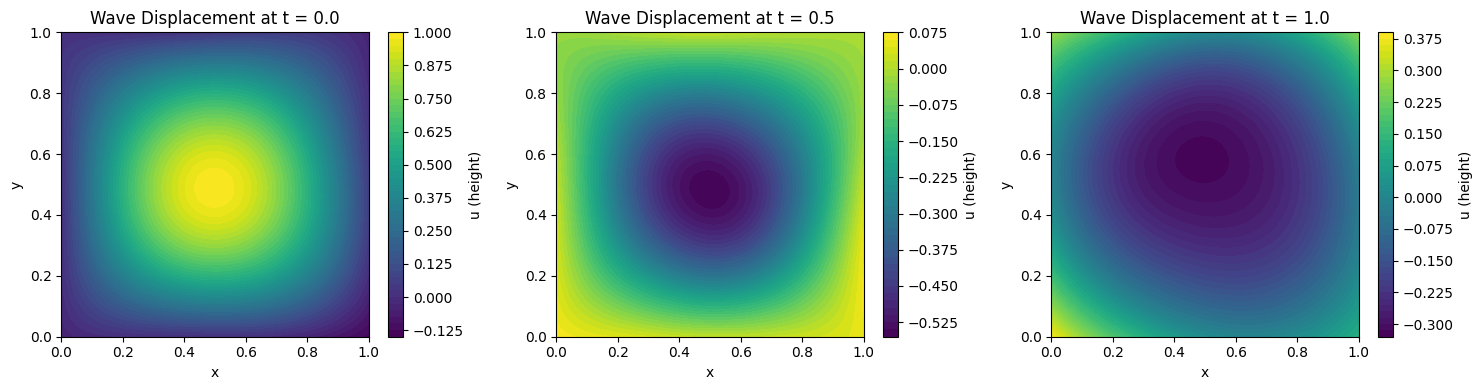

In [67]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 모델을 평가(추론) 모드로 전환
model.eval()

# 2. x, y 공간 격자(Grid) 생성 (0 ~ 1 범위)
x_val = np.linspace(0, 1, 100)
y_val = np.linspace(0, 1, 100)
X, Y = np.meshgrid(x_val, y_val)

# 모델 입력용 텐서로 변환 (형태 맞추기)
X_flat = torch.tensor(X.flatten(), dtype=torch.float32).unsqueeze(1)
Y_flat = torch.tensor(Y.flatten(), dtype=torch.float32).unsqueeze(1)

# 3. 관찰할 시간대(t) 설정
times = [0.0, 0.5, 1.0]

# 3개의 그래프를 나란히 그리기 위한 설정
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, t_val in enumerate(times):
    # 각 그래프에 해당하는 시간 t 텐서 생성
    T_flat = torch.full_like(X_flat, t_val)

    # 역전파(기울기 계산)를 끄고 모델 예측치(파동 변위 u) 계산
    with torch.no_grad():
        U_pred = model(X_flat, Y_flat, T_flat).cpu().numpy()

    # 평탄화된 예측값을 다시 2D 그리드 형태로 복구
    U_grid = U_pred.reshape(X.shape)

    # 등고선 그래프 (Contour plot) 생성
    c = axes[i].contourf(X, Y, U_grid, levels=50, cmap='viridis')
    axes[i].set_title(f"Wave Displacement at t = {t_val}")
    axes[i].set_xlabel("x")
    axes[i].set_ylabel("y")

    # 컬러바(Wave 높이) 표시
    fig.colorbar(c, ax=axes[i], label="u (height)")

plt.tight_layout()
plt.show()